In [ ]:
!wget https://raw.githubusercontent.com/AviSoori1x/makeMoE/main/input.txt


--2026-03-29 08:58:59--  https://raw.githubusercontent.com/AviSoori1x/makeMoE/main/input.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1115394 (1.1M) [text/plain]
Saving to: ‘input.txt.1’

input.txt.1         100%[===================>]   1.06M  --.-KB/s    in 0.05s   

2026-03-29 08:58:59 (21.0 MB/s) - ‘input.txt.1’ saved [1115394/1115394]



In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from dataclasses import dataclass
import math

In [ ]:

class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        # regularization
        self.attn_dropout = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head = config.n_head
        self.n_embd = config.n_embd
        self.dropout = config.dropout
        # flash attention make GPU go brrrrr but support is only in PyTorch >= 2.0

        # causal mask to ensure that attention is only applied to the left in the input sequence
        self.register_buffer("bias", torch.tril(torch.ones(config.block_size, config.block_size))
                                        .view(1, 1, config.block_size, config.block_size))

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)

        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        q, k, v  = self.c_attn(x).split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)

        # causal self-attention; Self-attend: (B, nh, T, hs) x (B, nh, hs, T) -> (B, nh, T, T)

            # manual implementation of attention
        att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
        att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
        att = F.softmax(att, dim=-1)
        att = self.attn_dropout(att)
        y = att @ v # (B, nh, T, T) x (B, nh, T, hs) -> (B, nh, T, hs)
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side

        # output projection
        y = self.resid_dropout(self.c_proj(y))
        return y

In [ ]:
@dataclass
class GPTConfig:
    block_size: int = 8
    vocab_size: int = 65 # GPT-2 vocab_size of 50257, padded up to nearest multiple of 64 for efficiency
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 64
    dropout: float = 0.1
    bias: bool = False # True: bias in Linears and LayerNorms, like GPT-2. False: a bit better and faster


In [ ]:

# read it in to inspect it
with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

In [ ]:
# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
print(''.join(chars))
print(vocab_size)


 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz
65


In [ ]:
attn = CausalSelfAttention(GPTConfig())

In [ ]:
sum([p.nelement() for p in attn.parameters()])

16384

In [ ]:
dropout = 0.1

In [ ]:
print("length of dataset in characters: ", len(text))


length of dataset in characters:  1115394


In [ ]:
class Expert(nn.Module):

  def __init__(self, n_embd):
    super().__init__()
    self.mlp = nn.Sequential(
        nn.Linear(in_features= n_embd, out_features=n_embd * 4),
        nn.ReLU(),
        nn.Linear(n_embd * 4, n_embd),
        nn.Dropout(0.1)
    )
  def forward(self, x):
    return self.mlp(x)

In [ ]:
expert = Expert(64)

In [ ]:
sum([p.nelement() for p in expert.parameters()])

33088

In [ ]:
num_experts = 4
top_k = 2
num_embed = 32
bs = 16
block_size = 8
router = nn.Linear(num_embed, num_experts)



In [ ]:
x = torch.randn((bs, block_size, num_embed))

In [ ]:
logits = router(x)

In [ ]:
topk_logits, topk_indices = logits.topk(k = top_k, dim = -1)

In [ ]:
topk_logits.shape

torch.Size([16, 8, 2])

In [ ]:
logits[0, 0]

tensor([ 0.7271,  0.3319, -0.6792,  0.3620], grad_fn=<SelectBackward0>)

In [ ]:
logits.masked_fill(mask )

NameError: name 'mask' is not defined

In [ ]:
topk_logits[0, 0]

tensor([0.7271, 0.3620], grad_fn=<SelectBackward0>)

In [ ]:
float("-inf")

-inf

In [ ]:
src = torch.arange(1, 11).reshape((2, 5))
print(src)
index = torch.tensor([[0, 0, 0, 0, 1]])
torch.zeros(3, 5, dtype=src.dtype).scatter_(0, index, src)


tensor([[ 1,  2,  3,  4,  5],
        [ 6,  7,  8,  9, 10]])


tensor([[1, 2, 3, 4, 0],
        [0, 0, 0, 0, 5],
        [0, 0, 0, 0, 0]])

In [ ]:
sparse_logits = (torch.zeros_like(logits) + float("-inf")).scatter(-1, topk_indices, topk_logits)

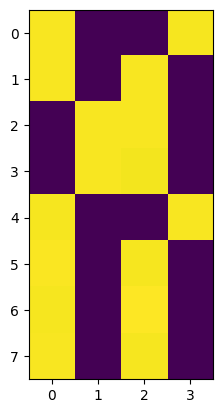

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(sparse_logits[0].clamp(-100, 100).detach().numpy())

In [ ]:
gating_outputs = F.softmax(sparse_logits, dim = -1)

In [ ]:
gating_outputs

tensor([[[0.5903, 0.0000, 0.0000, 0.4097],
         [0.5133, 0.0000, 0.4867, 0.0000],
         [0.0000, 0.5026, 0.4974, 0.0000],
         [0.0000, 0.6858, 0.3142, 0.0000],
         [0.4137, 0.0000, 0.0000, 0.5863],
         [0.7012, 0.0000, 0.2988, 0.0000],
         [0.1933, 0.0000, 0.8067, 0.0000],
         [0.5564, 0.0000, 0.4436, 0.0000]],

        [[0.5202, 0.0000, 0.4798, 0.0000],
         [0.6121, 0.0000, 0.3879, 0.0000],
         [0.6923, 0.0000, 0.3077, 0.0000],
         [0.0000, 0.2709, 0.7291, 0.0000],
         [0.0000, 0.0000, 0.4409, 0.5591],
         [0.0000, 0.3982, 0.6018, 0.0000],
         [0.0000, 0.5395, 0.0000, 0.4605],
         [0.5789, 0.4211, 0.0000, 0.0000]],

        [[0.0000, 0.0000, 0.4642, 0.5358],
         [0.4590, 0.0000, 0.0000, 0.5410],
         [0.4440, 0.0000, 0.5560, 0.0000],
         [0.3964, 0.0000, 0.6036, 0.0000],
         [0.0000, 0.5094, 0.0000, 0.4906],
         [0.6531, 0.0000, 0.0000, 0.3469],
         [0.4838, 0.0000, 0.5162, 0.0000],
       

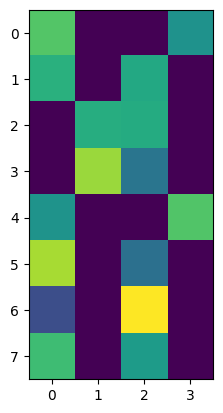

In [ ]:
plt.imshow(gating_outputs[0].detach().numpy())

In [ ]:
class TopkRouter(nn.Module):

  def __init__(self, n_embd, num_experts, topk):
    super().__init__()
    self.topk = topk
    self.linear = nn.Linear(n_embd, num_experts)
  def forward(self, x):
    logits = self.linear(x)
    topk_logits, topk_indices = logits.topk(self.topk, dim = -1)
    sparse_logits = (torch.zeros_like(logits) + float("-inf")).scatter(-1, topk_indices, topk_logits)
    gated_output = F.softmax(sparse_logits, dim = -1)
    return gated_output, topk_indices

In [ ]:
x.shape

torch.Size([16, 8, 32])

In [ ]:
router_test = TopkRouter(32, 4, 2)

In [ ]:
router_test.linear.weight.data.shape

torch.Size([4, 32])

In [ ]:
[p for p in router_test.parameters()]

[Parameter containing:
 tensor([[ 0.1461,  0.1111,  0.1074,  0.1607, -0.1065,  0.1400, -0.0089,  0.1069,
          -0.1612,  0.0314,  0.1547, -0.0648, -0.1509,  0.1164, -0.1472, -0.1580,
          -0.1329, -0.0402,  0.0183,  0.0702, -0.1095,  0.0957,  0.0251, -0.0719,
          -0.0835,  0.0941, -0.0631,  0.0243, -0.1202, -0.1707,  0.0415,  0.1616],
         [ 0.1671, -0.1594, -0.0331, -0.1407, -0.0557, -0.0237,  0.1708, -0.0712,
          -0.1285,  0.0226,  0.1514,  0.1009,  0.0105, -0.0213,  0.0800, -0.1595,
           0.1375,  0.1618, -0.0589,  0.0476, -0.1104,  0.0063,  0.0931,  0.0055,
          -0.1154, -0.0493,  0.1156,  0.1470,  0.1074, -0.0020, -0.1534,  0.1492],
         [ 0.0779, -0.0843, -0.0379, -0.0609,  0.0484, -0.0386,  0.0770, -0.1706,
           0.1197,  0.0997, -0.1143, -0.1200, -0.0771,  0.1102,  0.1110,  0.1539,
          -0.0485,  0.1566, -0.1395, -0.0208,  0.0420, -0.0156,  0.1157,  0.0572,
           0.1097,  0.1075, -0.1740, -0.0110,  0.0447, -0.0441, -0.1347, 

In [ ]:
router_test.linear.bias.data

tensor([-0.0806,  0.0881,  0.0762, -0.1690])

In [ ]:
router_test.linear.weight.data = router.weight.data
router_test.linear.bias.data = router.bias.data

In [ ]:
router_test.linear.weight.data.shape

torch.Size([4, 32])

In [ ]:
#Testing this out:
num_experts = 4
top_k = 2
n_embd = 32

mh_output = torch.randn(2, 4, n_embd)  # Example input
top_k_gate = TopkRouter(n_embd, num_experts, top_k)
gating_output, indices = top_k_gate(mh_output)
gating_output.shape, gating_output, indices

(torch.Size([2, 4, 4]),
 tensor([[[0.5226, 0.4774, 0.0000, 0.0000],
          [0.4069, 0.0000, 0.5931, 0.0000],
          [0.4998, 0.0000, 0.0000, 0.5002],
          [0.0000, 0.5944, 0.4056, 0.0000]],
 
         [[0.0000, 0.5026, 0.4974, 0.0000],
          [0.4694, 0.5306, 0.0000, 0.0000],
          [0.7693, 0.0000, 0.2307, 0.0000],
          [0.4805, 0.0000, 0.0000, 0.5195]]], grad_fn=<SoftmaxBackward0>),
 tensor([[[0, 1],
          [2, 0],
          [3, 0],
          [1, 2]],
 
         [[1, 2],
          [1, 0],
          [0, 2],
          [3, 0]]]))

In [ ]:
class NoisyTopkRouter(nn.Module):

  def __init__(self, n_embd, num_experts, topk):
    super().__init__()
    self.topk = topk
    self.topklinear = nn.Linear(n_embd, num_experts)
    self.noise_linear = nn.Linear(n_embd, num_experts)
  def forward(self, x):
    logits = self.topklinear(x)
    scale = self.noise_linear(x)
    noise = torch.randn_like(logits) * F.softplus(scale)
    noisy_logits = logits + noise
    topk_logits, topk_indices = logits.topk(self.topk, dim = -1)
    sparse_logits = (torch.zeros_like(logits) + float("-inf")).scatter(-1, topk_indices, topk_logits)
    gated_output = F.softmax(sparse_logits, dim = -1)
    return gated_output, topk_indices


In [ ]:
noisy_router = NoisyTopkRouter(32, num_experts=4, topk=2)

In [ ]:
gating_output, indices = noisy_router(mh_output)
gating_output.shape, gating_output, indices

(torch.Size([2, 4, 4]),
 tensor([[[0.0000, 0.6111, 0.3889, 0.0000],
          [0.0000, 0.6011, 0.3989, 0.0000],
          [0.0000, 0.0000, 0.3580, 0.6420],
          [0.0000, 0.5780, 0.4220, 0.0000]],
 
         [[0.0000, 0.4732, 0.5268, 0.0000],
          [0.0000, 0.3503, 0.0000, 0.6497],
          [0.0000, 0.0000, 0.3521, 0.6479],
          [0.4029, 0.5971, 0.0000, 0.0000]]], grad_fn=<SoftmaxBackward0>),
 tensor([[[1, 2],
          [1, 2],
          [3, 2],
          [1, 2]],
 
         [[2, 1],
          [3, 1],
          [3, 2],
          [1, 0]]]))

In [ ]:
(indices == 0).shape

torch.Size([2, 4, 2])

In [ ]:
expert = Expert(n_embd=32)

In [ ]:
expert_mask = (indices == 0).any(dim=-1)
flat_mask = expert_mask.view(-1)
expert_input = mh_output.view(-1, 32)[flat_mask]
expert_output = expert(expert_input)
expert_output.shape

torch.Size([1, 32])

In [ ]:
final_output = torch.zeros_like(mh_output)
final_output.shape

torch.Size([2, 4, 32])

In [ ]:
flat_mask

tensor([False,  True,  True,  True,  True, False, False,  True])

In [ ]:
gating_scores = gating_output.view(-1, 4)[flat_mask, 0]

In [ ]:
expert_output.shape, gating_scores.view(-1, 1).shape

(torch.Size([5, 32]), torch.Size([5, 1]))

In [ ]:
weighted_output = (expert_output * gating_scores.view(-1, 1))

In [ ]:
expert_mask = (indices == 0).any(dim=-1)
flat_mask = expert_mask.view(-1)
expert_input = mh_output.view(-1, 32)[flat_mask]
expert_output = expert(expert_input)
gating_scores = gating_output.view(-1, 4)[flat_mask, 0]
weighted_output = (expert_output * gating_scores.view(-1, 1))
final_output[expert_mask] += weighted_output

In [ ]:
flat_mask

tensor([False,  True,  True,  True,  True, False, False,  True])

In [ ]:
gating_output.view(-1, 4).shape

torch.Size([8, 4])

In [ ]:
(indices == 0).any(-1)

tensor([[False,  True,  True,  True],
        [ True, False, False,  True]])

In [ ]:
weighted_output.shape

torch.Size([5, 32])

In [ ]:
weighted_output.squeeze(1).shape

torch.Size([5, 32])

In [ ]:
final_output.shape

torch.Size([2, 4, 32])

In [ ]:
expert_mask.shape

torch.Size([2, 4])

In [ ]:
final_output[expert_mask] +=

torch.Size([5, 32])

In [ ]:
expert_output.shape

In [ ]:
(mh_output.view(-1, 32)[expert_mask.view(-1)])

torch.Size([5, 32])

In [ ]:
8 -> is thoken

In [ ]:
(indices == 0)

tensor([[[False, False],
         [ True, False],
         [ True, False],
         [False,  True]],

        [[False,  True],
         [False, False],
         [False, False],
         [False,  True]]])

In [ ]:
mh_output.view(-1, mh_output.size(-1)).shape

torch.Size([8, 32])

In [ ]:
gating_output.view(-1, gating_output.size(-1)).shape

torch.Size([8, 4])

In [ ]:
flat_x = x.view(-1, x.size(-1))


tensor([[2, 3],
        [0, 1],
        [0, 3],
        [2, 0],
        [2, 0],
        [1, 2],
        [2, 3],
        [1, 0]])

In [ ]:
class SparseMoE(nn.Module):

  def __init__(self, n_embd, num_experts, topk):
    super().__init__()

    self.router = NoisyTopkRouter(n_embd, num_experts, topk)
    self.experts = nn.ModuleList([Expert(n_embd) for _ in range(num_experts)])
    self.topk = topk

  def forward(self, x):
    gating_output, indices = self.router(x)
    final_output = torch.zeros_like(x)

    flat_x = x.view(-1, x.size(-1))
    flat_gating_output = gating_output.view(-1, gating_output.size(-1))

    for i, expert in enumerate(self.experts):
      expert_mask = (indices == i).any(-1)
      flat_mask = expert_mask.view(-1)

      if flat_mask.any():
        expert_input = flat_x[flat_mask]
        expert_output = expert(expert_input)
        gating_scores = flat_gating_output[flat_mask, i].view(-1, 1)
        weighted_output = expert_output * gating_scores
        final_output[expert_mask] += weighted_output
    return final_output


In [ ]:
import torch
import torch.nn as nn

#Let's test this out
num_experts = 8
top_k = 2
n_embd = 16
dropout=0.1

mh_output = torch.randn(4, 8, n_embd)  # Example multi-head attention output
sparse_moe = SparseMoE(n_embd, num_experts, top_k)
final_output = sparse_moe(mh_output)
print("Shape of the final output:", final_output.shape)

Shape of the final output: torch.Size([4, 8, 16])


In [ ]:
sum([p.nelement() for p in sparse_moe.parameters()])

17296

In [ ]:
def num_parameters(model):
  return sum([p.nelement() for p in model.parameters()])

In [ ]:
sum([p.nelement() for p in sparse_moe.experts[0].parameters()])

2128

In [ ]:
sum([p.nelement() for p in sparse_moe.router.parameters()])

272

In [ ]:
class Block(nn.Module):

  def __init__(self, config):
    super().__init__()

    self.sa = CausalSelfAttention(config)
    self.sparse_moe = SparseMoE(config.n_embd, config.num_experts, config.top_k)
    self.ln1 = nn.LayerNorm(config.n_embd)
    self.ln2 = nn.LayerNorm(config.n_embd)
  def forward(self, x):

    x = x + self.sa(self.ln1(x))
    x = x + self.sparse_moe(self.ln2(x))
    return x

In [ ]:
@dataclass
class GPTConfig:
    block_size: int = 32
    vocab_size: int = 65 # GPT-2 vocab_size of 50257, padded up to nearest multiple of 64 for efficiency
    n_layer: int = 4
    n_head: int = 4
    n_embd: int = 64
    dropout: float = 0.1
    num_experts : int = 8
    top_k : int = 2
    bias: bool = False # True: bias in Linears and LayerNorms, like GPT-2. False: a bit better and faster


In [ ]:
block = Block(GPTConfig())

In [ ]:
num_parameters(block)

282384

In [ ]:
torch.arange(8, device="cpu")

tensor([0, 1, 2, 3, 4, 5, 6, 7])

In [ ]:
position_embedding_table = nn.Embedding(8, 32)

position_embedding_table(torch.arange(8, device="cpu")).shape

torch.Size([8, 32])

In [ ]:
class SparseMoELanguageModel(nn.Module):

    def __init__(self, config):
        super().__init__()
        # each token directly reads off the logits for the next token from a lookup table
        self.token_embedding_table = nn.Embedding(config.vocab_size, config.n_embd)
        self.position_embedding_table = nn.Embedding(config.block_size, config.n_embd)
        self.blocks = nn.Sequential(*[Block(config) for _ in range(config.n_layer)])
        self.ln_f = nn.LayerNorm(config.n_embd) # final layer norm
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size)
        self.config = config
    def forward(self, idx, targets=None):
        B, T = idx.shape

        tok_emb = self.token_embedding_table(idx) # (B,T,C)
        pos_emb = self.position_embedding_table(torch.arange(T, device=idx.device)) # (T,C)
        x = tok_emb + pos_emb # (B,T,C)
        x = self.blocks(x) # (B,T,C)
        x = self.ln_f(x) # (B,T,C)
        logits = self.lm_head(x) # (B,T,vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape
            logits = logits.view(B*T, C)
            targets = targets.view(B*T)
            loss = F.cross_entropy(logits, targets)

        return logits, loss
    def generate(self, idx, max_new_tokens):
        for _ in range(max_new_tokens):
          idx_cond = idx[:, -self.config.block_size : ]
          logits, loss = model(idx_cond) # logits _> (B, T, vocab_size)
          logits = logits[:, -1, :] # b, vocab_size
          probs = F.softmax(logits, dim = -1)
          idx_next = torch.multinomial(probs, 1)
          idx = torch.cat([idx, idx_next], dim = -1)
        return idx

In [ ]:
model = SparseMoELanguageModel(GPTConfig())


In [ ]:
idx = torch.randint(0, 65, (16, 8))

In [ ]:
logits, loss = model(idx)

In [ ]:
probs = F.softmax(logits[:, -1, :], -1)

In [ ]:
idx_next = torch.multinomial(probs, 1)

In [ ]:
torch.cat([idx, idx_next], dim = 1).shape

torch.Size([16, 9])

In [ ]:
x_sample = model.generate(idx, 100)

In [ ]:

#First defining hyperparameters and boiler plate code. Imports and data preparation code is repeated for convenience
import torch
import torch.nn as nn
from torch.nn import functional as F
from torch.nn import init

# hyperparameters
batch_size = 64 # how many independent sequences will we process in parallel?
block_size = 256 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 100
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 50
head_size = 16
n_embed = 128
n_head = 8
n_layer = 8
dropout = 0.1
num_experts = 8
top_k = 2
# ------------
@dataclass
class GPTConfig:
    block_size: int = 256
    vocab_size: int = 65 # GPT-2 vocab_size of 50257, padded up to nearest multiple of 64 for efficiency
    n_layer: int = 8
    n_head: int = 8
    n_embd: int = 128
    dropout: float = 0.1
    num_experts : int = 8
    top_k : int = 2
    bias: bool = False # True: bias in Linears and LayerNorms, like GPT-2. False: a bit better and faster
torch.manual_seed(1337)
model = SparseMoELanguageModel(GPTConfig())

with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# here are all the unique characters that occur in this text
chars = sorted(list(set(text)))
vocab_size = len(chars)
# create a mapping from characters to integers
stoi = { ch:i for i,ch in enumerate(chars) }
itos = { i:ch for i,ch in enumerate(chars) }
encode = lambda s: [stoi[c] for c in s] # encoder: take a string, output a list of integers
decode = lambda l: ''.join([itos[i] for i in l]) # decoder: take a list of integers, output a string

# Train and test splits
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out


In [ ]:
eval_iters

400

In [ ]:
from tqdm import tqdm
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
#mlflow.set_experiment("makeMoE")
    #If you use mlflow.autolog() this will be automatically logged. I chose to explicitly log here for completeness

for iter in tqdm(range(max_iters)):

  # every once in a while evaluate the loss on train and val sets
  if iter % eval_interval == 0 or iter == max_iters - 1:
    losses = estimate_loss()
    print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")


  # sample a batch of data
  xb, yb = get_batch('train')

  # evaluate the loss
  logits, loss = model(xb, yb)
  optimizer.zero_grad(set_to_none=True)
  loss.backward()
  optimizer.step()

9.024193 M parameters


  0%|          | 0/5000 [00:00<?, ?it/s]

step 0: train loss 4.3245, val loss 4.3195


  2%|▏         | 100/5000 [00:27<16:54,  4.83it/s]

step 100: train loss 2.4679, val loss 2.4831


...

step 1900: train loss 1.2055, val loss 1.5086


 40%|████      | 2000/5000 [08:55<10:29,  4.77it/s]

step 2000: train loss 1.1998, val loss 1.5072


 41%|████      | 2058/5000 [09:13<13:11,  3.72it/s]


KeyboardInterrupt: 

In [ ]:

# generate from the model. Not great. Not too bad either
context = torch.zeros((1, 1), dtype=torch.long, device=device)
print(decode(m.generate(context, max_new_tokens=2000)[0].tolist()))


INGELO:
I warray truly is call earn to ever that their senate:
her is his faults and help call those and piece ti
to our tear. When it seeks fitter. What, ogses they not
upon your four passarvour of his faulse is being
he tiddstay: there is too a phease and earth
hate too the grarmed to be kill'd whiter; every smoothing
how I do and repent. Either ever the crimes aimation co
suppliaring to black a never begished:
Nay is confession? Come to me and duest afflict.

CLAUDIO:
Well, that Master
To make held a rise, of the sea,
Not so. Trow Oxfoord wretched ben the vereins
Divine to at his couchsess; whom thou slack to so his choerse
Encounteral that we make a man urgeduin,
Makes thy sspake, when be true of a king
Ponderly makes, it is itself and
The help of countenance held scorn, when had
Thus as it, but he shall may pay thy hands
And hand the that most any tongue fond
This mann but dump the oracle's siless rise.
Bearing thee, whom looks upon it learness
Of thy plot Florence into what any


In [ ]:
import tiktoken

In [ ]:
tokenizer = tiktoken.get_encoding("gpt2")

In [ ]:
tokenizer.n_vocab

50257

In [ ]:
print("char level tokenization lenght: ", len(data))

char level tokenization lenght:  1115394


## byte pair algorithm

In [ ]:
# hyperparameters
batch_size = 64 # how many independent sequences will we process in parallel?
block_size = 256 # what is the maximum context length for predictions?
max_iters = 5000
eval_interval = 100
learning_rate = 1e-3
device = 'cuda' if torch.cuda.is_available() else 'cpu'
eval_iters = 50
head_size = 16
n_embed = 128
n_head = 8
n_layer = 8
dropout = 0.1
num_experts = 8
top_k = 2
# ------------
@dataclass
class GPTConfig:
    block_size: int = 256
    vocab_size: int = 50257 # GPT-2 vocab_size of 50257, padded up to nearest multiple of 64 for efficiency
    n_layer: int = 8
    n_head: int = 8
    n_embd: int = 128
    dropout: float = 0.1
    num_experts : int = 8
    top_k : int = 2
    bias: bool = False # True: bias in Linears and LayerNorms, like GPT-2. False: a bit better and faster
torch.manual_seed(1337)
model = SparseMoELanguageModel(GPTConfig())

with open('input.txt', 'r', encoding='utf-8') as f:
    text = f.read()

# here are all the unique characters that occur in this text
vocab_size = tokenizer.n_vocab

encode = lambda s: tokenizer.encode(s) # encoder: take a string, output a list of integers
decode = lambda l: tokenizer.decode(l) # decoder: take a list of integers, output a string

# Train and test splits
data = torch.tensor(encode(text), dtype=torch.long)
n = int(0.9*len(data)) # first 90% will be train, rest val
train_data = data[:n]
val_data = data[n:]

# data loading
def get_batch(split):
    # generate a small batch of data of inputs x and targets y
    data = train_data if split == 'train' else val_data
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([data[i:i+block_size] for i in ix])
    y = torch.stack([data[i+1:i+block_size+1] for i in ix])
    x, y = x.to(device), y.to(device)
    return x, y

@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model.train()
    return out


In [ ]:
print("byte pair algorithm tokenization lenght: ", len(data))

byte pair algorithm tokenization lenght:  338025


In [ ]:
from tqdm import tqdm
m = model.to(device)
# print the number of parameters in the model
print(sum(p.numel() for p in m.parameters())/1e6, 'M parameters')

# create a PyTorch optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)
#mlflow.set_experiment("makeMoE")
    #If you use mlflow.autolog() this will be automatically logged. I chose to explicitly log here for completeness

for iter in tqdm(range(max_iters)):

  # every once in a while evaluate the loss on train and val sets
  if iter % eval_interval == 0 or iter == max_iters - 1:
    losses = estimate_loss()
    print(f"step {iter}: train loss {losses['train']:.4f}, val loss {losses['val']:.4f}")


  # sample a batch of data
  xb, yb = get_batch('train')

  # evaluate the loss
  logits, loss = model(xb, yb)
  optimizer.zero_grad(set_to_none=True)
  loss.backward()
  optimizer.step()

21.923537 M parameters


  0%|          | 0/5000 [00:00<?, ?it/s]

step 0: train loss 11.0152, val loss 11.0163


  2%|▏         | 100/5000 [00:33<21:56,  3.72it/s]

step 100: train loss 5.3551, val loss 5.6663


...

step 600: train loss 3.5468, val loss 4.7722


 14%|█▍        | 700/5000 [04:08<19:10,  3.74it/s]

step 700: train loss 3.3410, val loss 4.8233


 15%|█▍        | 728/5000 [04:25<25:57,  2.74it/s]


KeyboardInterrupt: 